<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW3/HW3_Seq2Seq_Q3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW3

#Imports

In [1]:
import torch
import torch.nn as nn
import torch.functional as F

import matplotlib.pyplot as plt
import numpy as np

import requests

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torch import optim

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
url = "https://raw.githubusercontent.com/JordanTerwilliger/Intro-to-Deep-Learning/refs/heads/main/HW3/vast_english_french.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

#Preprocessing

In [3]:
def tokenize_and_pad(sentences, vocab):
    # Calculate the maximum sentence length for padding
    max_length = max(len(sentence.split(' ')) for sentence in sentences) + 2  # +2 for SOS and EOS tokens
    tokenized_sentences = []
    for sentence in sentences:
        # Convert each sentence to a list of indices, adding SOS and EOS tokens
        tokens = [vocab.word2index["<SOS>"]] + [vocab.word2index[word] for word in sentence.split(' ')] + [vocab.word2index["<EOS>"]]
        # Pad sentences to the maximum length
        padded_tokens = tokens + [vocab.word2index["<PAD>"]] * (max_length - len(tokens))
        tokenized_sentences.append(padded_tokens)
    return torch.tensor(tokenized_sentences, dtype=torch.long)

In [4]:
# Vocabulary class to handle mapping between words and numerical indices
class Vocabulary:
  def __init__(self):
    #Dictionaries for special tokens and reverse
    self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
    self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
    self.word_count = {}  # Keep track of word frequencies
    self.n_words = 3  # Start counting from 3 to account for special tokens

  def add_sentence(self, sentence):
    # Add all words in a sentence to the vocabulary
    for word in sentence.split(' '):
      self.add_word(word)

  def add_word(self, word):
        # Add a word to the vocabulary
        if word not in self.word2index:
            # Assign a new index to the word and update mappings
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            # Increment word count if the word already exists in the vocabulary
            self.word_count[word] += 1

In [5]:
class EngFrDataset(Dataset):
    def __init__(self, pairs):
        self.eng_vocab = Vocabulary()
        self.fr_vocab = Vocabulary()
        self.pairs = []

        # Process each English-French pair
        for eng, fr in pairs:
            self.eng_vocab.add_sentence(eng)
            self.fr_vocab.add_sentence(fr)
            self.pairs.append((eng, fr))

        # Separate English and French sentences
        self.eng_sentences = [pair[0] for pair in self.pairs]
        self.fr_sentences = [pair[1] for pair in self.pairs]

        # Tokenize and pad sentences
        self.eng_tokens = tokenize_and_pad(self.eng_sentences, self.eng_vocab)
        self.fr_tokens = tokenize_and_pad(self.fr_sentences, self.fr_vocab)

    def __len__(self):
        # Return the number of sentence pairs
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get the tokenized and padded sentences by index
        eng_tokens = self.eng_tokens[idx]
        fr_tokens = self.fr_tokens[idx]
        return eng_tokens, fr_tokens

In [6]:
pairs = [
    tuple(part.strip() for part in line.split('\t')) for line in text.splitlines() if '\t' in line
]

dataset = EngFrDataset(pairs)

train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

idx2w_e = dataset.eng_vocab.index2word
idx2w_f = dataset.fr_vocab.index2word
print(idx2w_e)
print(idx2w_f)
batch_size = 256
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: 'I', 4: 'am', 5: 'cold', 6: 'You', 7: 'are', 8: 'tired', 9: 'He', 10: 'is', 11: 'hungry', 12: 'She', 13: 'happy', 14: 'We', 15: 'friends', 16: 'They', 17: 'students', 18: 'The', 19: 'cat', 20: 'sleeping', 21: 'sun', 22: 'shining', 23: 'love', 24: 'music', 25: 'speaks', 26: 'French', 27: 'fluently', 28: 'enjoys', 29: 'reading', 30: 'books', 31: 'play', 32: 'soccer', 33: 'every', 34: 'weekend', 35: 'movie', 36: 'starts', 37: 'at', 38: '7', 39: 'PM', 40: 'wears', 41: 'a', 42: 'red', 43: 'dress', 44: 'cook', 45: 'dinner', 46: 'together', 47: 'drives', 48: 'blue', 49: 'car', 50: 'visit', 51: 'museums', 52: 'often', 53: 'restaurant', 54: 'serves', 55: 'delicious', 56: 'food', 57: 'studies', 58: 'mathematics', 59: 'university', 60: 'watch', 61: 'movies', 62: 'on', 63: 'Fridays', 64: 'listens', 65: 'to', 66: 'while', 67: 'jogging', 68: 'travel', 69: 'around', 70: 'the', 71: 'world', 72: 'book', 73: 'table', 74: 'dances', 75: 'gracefully', 76: 'celebrate'

#Model Creation

In [7]:
class Encoder(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(Encoder,self).__init__()
    self.hidden_size = hidden_size
    self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=0) #num_embeddings, embedding_dim
    self.dropout = nn.Dropout(p = 0.2)
    self.rnn = nn.GRU(hidden_size, hidden_size, batch_first = True)

  def forward(self, input_tensor):
    embedded = self.embedding(input_tensor)
    output = self.dropout(embedded)
    output, hidden = self.rnn(output)
    return output, hidden #Hidden is the input to the decoder, Input -> Encoder -> Encoder Output + Hidden State -> Decoder -> Output

class Decoder(nn.Module):
  def __init__(self, output_size, hidden_size):
    super(Decoder, self).__init__()
    self.hidden_size = hidden_size
    self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=0) #num_embeddings, embedding_dim
    self.dropout = nn.Dropout(p = 0.2)
    self.rnn = nn.GRU(hidden_size, hidden_size, batch_first = True)
    self.out = nn.Linear(hidden_size, output_size)

  def forward(self, input_tensor, hidden_state):
    embedded = self.embedding(input_tensor)
    output = self.dropout(embedded)
    output, hidden_state = self.rnn(output, hidden_state)
    output = self.out(output.squeeze(1))
    return output, hidden_state

In [8]:
input_size = len(dataset.fr_vocab.index2word)
hidden_size = 256
output_size = len(dataset.eng_vocab.index2word)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = Decoder(output_size, hidden_size).to(device)

learning_rate = 0.001
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=0)


#Training Loop


In [9]:

PAD = 0
SOS = 1
EOS = 2

def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
  encoder.train()
  decoder.train()

  encoder_optimizer.zero_grad()
  decoder_optimizer.zero_grad()

  batch_size = input_tensor.size(0)
  target_length = target_tensor.size(1)

  encoder_output, encoder_hidden = encoder(input_tensor)

  decoder_input = torch.full((batch_size, 1), SOS, device=device)
  decoder_hidden = encoder_hidden

  decoder_outputs = []

  # Start from 1 to skip predicting the <SOS> token
  for di in range(1, target_length):
    decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
    decoder_outputs.append(decoder_output)

    _, topi = decoder_output.topk(1) # Get the index of the best prediction
    decoder_input = topi.detach() # Detach from history as input

  decoder_outputs = torch.stack(decoder_outputs, dim=1) # [batch, seq_len-1, vocab_size]
  # Shift targets to match outputs (skip the initial <SOS>)
  targets = target_tensor[:, 1:]
  loss = criterion(decoder_outputs.reshape(-1, decoder_outputs.size(-1)), targets.reshape(-1))

  loss.backward()
  encoder_optimizer.step()
  decoder_optimizer.step()

  return loss.item()


def test(input_tensor, target_tensor, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()

    batch_size = input_tensor.size(0)
    target_length = target_tensor.size(1)
    correct = 0
    total_tokens = 0  # count only non-pad tokens

    with torch.no_grad():
        encoder_output, encoder_hidden = encoder(input_tensor)

        decoder_input = torch.full((batch_size, 1), SOS, device=device)
        decoder_hidden = encoder_hidden

        decoder_outputs = []

        for di in range(1, target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            _, topi = decoder_output.topk(1)
            decoder_input = topi.detach()

            target_step = target_tensor[:, di]
            mask = target_step != PAD
            correct += ((topi.squeeze(1) == target_step) & mask).sum().item()
            total_tokens += mask.sum().item()

        decoder_outputs = torch.stack(decoder_outputs, dim=1)
        targets = target_tensor[:, 1:]
        val_loss = criterion(decoder_outputs.reshape(-1, decoder_outputs.size(-1)), targets.reshape(-1))

    accuracy = correct / total_tokens if total_tokens > 0 else 0.0
    return val_loss.item(), accuracy

In [10]:
epochs = 125
val_loss_list = []
train_loss_list = []

print("Starting Training...")
for epoch in range(epochs):
  total_loss = 0
  total_val_loss = 0
  total_val_accuracy = 0

  for target_tensor, input_tensor in train_loader:
    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)
    loss = train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
    total_loss += loss
  train_loss_list.append(total_loss)

  for target_tensor, input_tensor in test_loader:
    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)
    val_loss, val_accuracy = test(input_tensor, target_tensor, encoder, decoder, criterion)
    total_val_loss += val_loss
    total_val_accuracy += val_accuracy

  val_loss_list.append(total_val_loss)

  # Only print every 10 epochs to reduce output spam
  if epoch % 10 == 0 or epoch == epochs - 1:
      print(f"Epoch {epoch}, Train Loss: {(total_loss / len(train_loader)):.4f}, Val Loss: {(total_val_loss / len(test_loader)):.4f}, Val Accuracy: {(total_val_accuracy / len(test_loader)):.4f}")


Starting Training...
Epoch 0, Train Loss: 6.9068, Val Loss: 6.7614, Val Accuracy: 0.0747
Epoch 10, Train Loss: 4.7792, Val Loss: 5.1428, Val Accuracy: 0.1972
Epoch 20, Train Loss: 4.4555, Val Loss: 5.2222, Val Accuracy: 0.1972
Epoch 30, Train Loss: 4.2132, Val Loss: 5.2165, Val Accuracy: 0.2899
Epoch 40, Train Loss: 3.8572, Val Loss: 4.9962, Val Accuracy: 0.3222
Epoch 50, Train Loss: 3.4934, Val Loss: 4.8946, Val Accuracy: 0.3273
Epoch 60, Train Loss: 3.2028, Val Loss: 4.8782, Val Accuracy: 0.3299
Epoch 70, Train Loss: 2.9884, Val Loss: 4.8977, Val Accuracy: 0.3415
Epoch 80, Train Loss: 2.8059, Val Loss: 4.9187, Val Accuracy: 0.3518
Epoch 90, Train Loss: 2.6099, Val Loss: 4.9196, Val Accuracy: 0.3711
Epoch 100, Train Loss: 2.3994, Val Loss: 4.8963, Val Accuracy: 0.3982
Epoch 110, Train Loss: 2.1859, Val Loss: 4.8473, Val Accuracy: 0.4111
Epoch 120, Train Loss: 1.9410, Val Loss: 4.8201, Val Accuracy: 0.4278
Epoch 124, Train Loss: 1.8479, Val Loss: 4.7976, Val Accuracy: 0.4330


In [11]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def BLEU(encoder, decoder, dataloader, n_examples=5):
  total_bleu_score = 0.0
  total_sentences = 0
  chencherry = SmoothingFunction()
  examples_printed = 0

  # Ensure models are in evaluation mode
  encoder.eval()
  decoder.eval()

  with torch.no_grad():
    for target_tensor, input_tensor in dataloader:
      input_tensor = input_tensor.to(device)
      target_tensor = target_tensor.to(device)

      batch_size = input_tensor.size(0)

      # 1. Pass entire batch through Encoder
      encoder_outputs, encoder_hidden = encoder(input_tensor)

      # 2. Setup Decoder for the batch
      decoder_input = torch.full((batch_size, 1), SOS, device=device)
      decoder_hidden = encoder_hidden

      # Tensor to store predictions for the whole batch: [batch_size, 20]
      max_gen_length = 20
      batch_predictions = torch.zeros(batch_size, max_gen_length, dtype=torch.long, device=device)

      # 3. Generate step (Process the whole batch at once)
      for di in range(max_gen_length):
          decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
          _, topi = decoder_output.topk(1) # topi shape: [batch_size, 1]

          # Store the predicted token for each sequence in the batch
          batch_predictions[:, di] = topi.squeeze(1)

          # Use predictions as the next input
          decoder_input = topi.detach()

      # 4. Convert to strings and calculate BLEU for each sentence in the batch
      for b in range(batch_size):
        inp_seq = input_tensor[b]
        tgt_seq = target_tensor[b]
        pred_seq = batch_predictions[b]

        # Helper function to convert indices to strings properly
        def to_string(seq, vocab, is_pred=False):
            words = []
            for idx in seq:
                val = idx.item()
                # For predictions, we MUST stop at the first EOS token
                if val == EOS and is_pred:
                    break
                # Ignore special tokens in the final readable string
                if val not in (SOS, EOS, PAD):
                    words.append(vocab[val])
            return ' '.join(words)

        input_string = to_string(inp_seq, idx2w_f)
        target_string = to_string(tgt_seq, idx2w_e)
        predicted_string = to_string(pred_seq, idx2w_e, is_pred=True)

        # --- EVALUATION: BLEU Score ---
        reference_tokens = [target_string.split()]
        candidate_tokens = predicted_string.split()

        bleu = sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=chencherry.method1)
        total_bleu_score += bleu
        total_sentences += 1

        # Print the first n_examples
        if examples_printed < n_examples:
          match_status = "PASS" if predicted_string == target_string else "FAIL"
          print(f'Input: {input_string:<20} | Target: {target_string:<20} | Predicted: {predicted_string:<20} | Match: {match_status:<4} | BLEU: {bleu:.4f}')
          examples_printed += 1

  # Calculate average across all processed sentences
  average_bleu = total_bleu_score / total_sentences
  print(f'\n -> Average Validation BLEU-4 Score : {average_bleu:.4f}')

  return average_bleu

In [12]:
BLEU(encoder, decoder, test_loader)

Input: Ils regardent un match de football | Target: They are watching a football match | Predicted: They live in the     | Match: FAIL | BLEU: 0.0487
Input: Fermez la fenêtre    | Target: Close the window     | Predicted: The teacher is the   | Match: FAIL | BLEU: 0.0803
Input: Il court cinq milles tous les matins avant le petit déjeuner | Target: He runs five miles every morning before breakfast | Predicted: He writes his for a advanced Friday | Match: FAIL | BLEU: 0.0286
Input: Nous apprenons quelque chose de nouveau chaque jour | Target: We learn something new every day | Predicted: We are going to the our the | Match: FAIL | BLEU: 0.0330
Input: La soupe est délicieuse | Target: The soup tastes delicious | Predicted: The map is a         | Match: FAIL | BLEU: 0.0803

 -> Average Validation BLEU-4 Score : 0.1532


0.1531996754836519

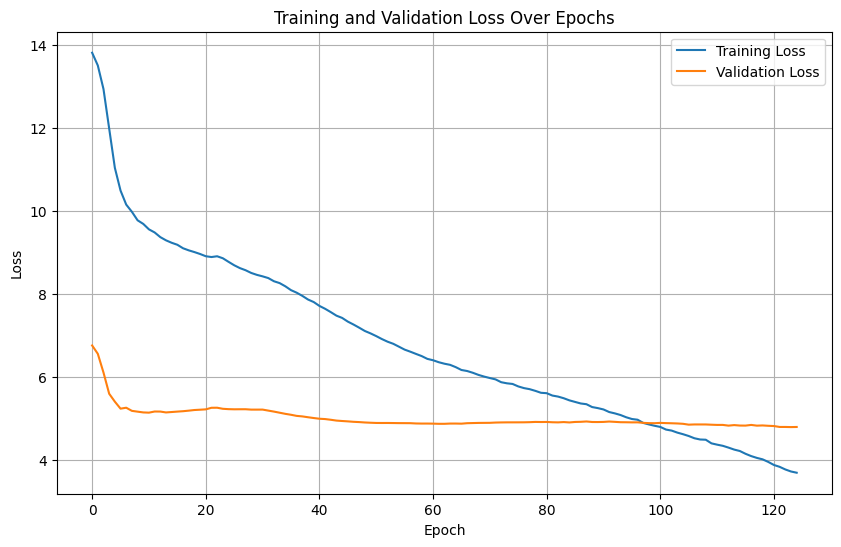

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()